In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from unittest.mock import AsyncMock, Mock, patch
import httpx
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from dotenv import load_dotenv
from matplotlib.colors import ListedColormap
from shapely.geometry import shape, Polygon
import gc

# Make sure your dotenv file has the following defined:
load_dotenv()
GIT_FOLDER = os.environ['GIT_FOLDER']
TITILER_URL = os.environ['TITILER_URL']
TITILER_API_KEY = os.environ['TITILER_API_KEY']
API_KEY = os.environ['API_KEY']
MODEL_PATH_LOCAL = os.environ['MODEL_PATH_LOCAL']

if not (GIT_FOLDER and TITILER_URL and TITILER_API_KEY and MODEL_PATH_LOCAL):
    print("ERRROR: Failed to find all the necessary environment variables!!!")
    # Note, you must restart the kernel if you want to load new environment variables

if GIT_FOLDER not in sys.path:
    sys.path.append(GIT_FOLDER)
print(sys.path)

from ensembler import Task, Ensemblers

['C:\\Users\\ebeva\\SkyTruth\\cerulean_cloud\\cerulean_local', 'C:\\Users\\ebeva\\AppData\\Local\\anaconda3\\envs\\CeruleanWork\\python311.zip', 'C:\\Users\\ebeva\\AppData\\Local\\anaconda3\\envs\\CeruleanWork\\DLLs', 'C:\\Users\\ebeva\\AppData\\Local\\anaconda3\\envs\\CeruleanWork\\Lib', 'C:\\Users\\ebeva\\AppData\\Local\\anaconda3\\envs\\CeruleanWork', '', 'C:\\Users\\ebeva\\AppData\\Local\\anaconda3\\envs\\CeruleanWork\\Lib\\site-packages', 'C:\\Users\\ebeva\\AppData\\Local\\anaconda3\\envs\\CeruleanWork\\Lib\\site-packages\\win32', 'C:\\Users\\ebeva\\AppData\\Local\\anaconda3\\envs\\CeruleanWork\\Lib\\site-packages\\win32\\lib', 'C:\\Users\\ebeva\\AppData\\Local\\anaconda3\\envs\\CeruleanWork\\Lib\\site-packages\\Pythonwin', 'C:\\Users\\ebeva\\SkyTruth\\git\\cerulean-cloud']


In [2]:
from cerulean_cloud.models import *
from cerulean_cloud.tiling import TMS, offset_bounds_from_base_tiles
from cerulean_cloud.titiler_client import TitilerClient
from cerulean_cloud.cloud_run_orchestrator.clients import img_array_to_b64_image
from cerulean_cloud.cloud_run_orchestrator.schema import OrchestratorInput
from cerulean_cloud.cloud_run_orchestrator.handler import *#_orchestrate, get_tiler, get_titiler_client, get_roda_sentinelhub_client, get_database_engine
from cerulean_cloud.cloud_run_offset_tiles.schema import * #import InferenceInput, PredictPayload
#from cerulean_cloud.cloud_run_offset_tiles.handler import predict

In [3]:
fastaiunet = {
    "type": "FASTAIUNET",
    "file_path": "",#"experiments/2024_03_06_18_14_31_7cls_rn101_pr256_z9_fastai_baseline_noamb/tracing_cpu_model.pt",
    "layers": ["VV"],
    "cls_map": {
        0: "BACKGROUND",
        1: "INFRA",
        2: "NATURAL",
        3: "COIN_VESSEL",
        4: "REC_VESSEL",
        5: "OLD_VESSEL",
        6: "BACKGROUND"  # HITL AMBIGUOUS, should never be output by inference_idx
    },  # inference_idx maps to class table
    "name": "ResNet101 Baseline Noamb",
    "tile_width_m": 40844,  # Used to calculate zoom
    "tile_width_px": 256,  # Used to calculate scale
    "epochs": 80,
    "thresholds": {
        "pixel_nms_thresh": 0.4,
        "bbox_score_thresh": 0.1,
        "poly_score_thresh": 0.01, # JONA Is this working correctly???
        "pixel_score_thresh": 0.35,
        "groundtruth_dice_thresh": 0.0
    },
    "backbone_size": 101,
    "zoom_level":9,
    "scale":2,
    # "pixel_f1": 0.0,  # TODO CALCULATE
    # "instance_f1": 0.0  # TODO CALCULATE
}

maskrcnn = dict(
    type="MASKRCNN",
    file_path="",#"experiments/2023_10_05_02_22_46_4cls_rnxt101_pr512_px1024_680min_maskrcnn_wd01/scripting_cpu_model.pt",
    layers=["VV", "ALL_255", "VESSEL"],
    cls_map={
        0: "BACKGROUND",
        1: "INFRA",
        2: "NATURAL",
        3: "VESSEL",
    },  # inference_idx maps to class table
    name="ResNext 101 hires56",
    tile_width_m=40844,
    tile_width_px=512,
    epochs=122,
    thresholds={
        "poly_nms_thresh": 0.2,
        'pixel_nms_thresh': 0.4,
        'bbox_score_thresh': 0.3,
        'poly_score_thresh': 0.1,
        'pixel_score_thresh': 0.5,
        'groundtruth_dice_thresh': 0.0
        },
    backbone_size=101,
    pixel_f1=0.461,
    instance_f1=0.47,
)

model_dict=maskrcnn

In [4]:
class MockLayer:
    def __init__(self, short_name, source_url):
        self.short_name = short_name
        self.source_url = source_url
layers_fastaiunet = [MockLayer("VV","https://registry.opendata.aws/sentinel-1/")]
layers_maskrcnn = [MockLayer("VV","https://registry.opendata.aws/sentinel-1/"),
           MockLayer("INFRA","https://storage.googleapis.com/ceruleanml/aux_datasets/infra_locations_01_cogeo.tiff"),
           MockLayer("VESSEL", "https://gmtds.maplarge.com/public/ext/GMTDS/Main")]
layers = layers_maskrcnn

In [5]:
async def get_titiler_client_and_offset_tiles(sentinel_scene, offset=.33):
    payload = OrchestratorInput(**sentinel_scene)
    TitilerClient_url = os.getenv('TITILER_URL')
    titiler_client = TitilerClient(url=TitilerClient_url)
    scene_bounds = await titiler_client.get_bounds(payload.sceneid)
    tiler = TMS
    base_tiles = list(tiler.tiles(*scene_bounds, [payload.zoom], truncate=False))
    offset_tile_bounds = offset_bounds_from_base_tiles(base_tiles, offset_amount=offset)
    return titiler_client, offset_tile_bounds

In [6]:
#scene_id = "S1A_IW_GRDH_1SDV_20230523T224049_20230523T224114_048667_05DA7A_91D1"
scene_id = "S1A_IW_GRDH_1SDV_20231121T015923_20231121T015948_051309_0630CB_AADA"
test_scene = {"sceneid": scene_id , "zoom":9, "scale":2}
payload = OrchestratorInput(**test_scene)
titiler_client = TitilerClient(url=os.getenv('TITILER_URL'))
tiler = TMS
scene_bounds = await titiler_client.get_bounds(test_scene['sceneid'])
zoom = test_scene['zoom']
scale = test_scene['scale']
start_time = 'now-o-clock'

2024-06-28 13:34:01,824 - httpx - INFO - HTTP Request: GET https://abltf296mk.execute-api.eu-central-1.amazonaws.com/bounds?sceneid=S1A_IW_GRDH_1SDV_20231121T015923_20231121T015948_051309_0630CB_AADA "HTTP/1.1 200 OK"


In [7]:
"""Clients for other cloud run functions"""

import asyncio
import json
import os
import zipfile
from base64 import b64encode
from datetime import datetime
from io import BytesIO
from typing import List, Tuple

import httpx
import numpy as np
import rasterio
import skimage
from rasterio.enums import Resampling
from rasterio.io import MemoryFile
from rasterio.plot import reshape_as_raster
from rio_tiler.io import COGReader

In [1]:
def plot_histo(array, range=None,ylim=None):
    if range==None:
        range=(0, 255)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title('Histogram of Pixel Values')
    if ylim !=None:
        plt.ylim(0, ylim)
    hist_values, bin_edges, _ = plt.hist(array.ravel(), bins=range[1], range=range, color='blue', alpha=0.7)
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    return hist_values, bin_edges[:-1]

In [8]:
class MockCloudRunInferenceClient(CloudRunInferenceClient):
    def __init__(
        self,
        url: str,
        titiler_client,
        sceneid: str,
        tileset_envelope_bounds: List[float],
        image_hw_pixels: Tuple[int, int],
        layers: List,
        scale: int,
        model_dict,
    ):
        super().__init__(url, titiler_client, sceneid, tileset_envelope_bounds, image_hw_pixels, layers, scale, model_dict)

    async def local_predict(self, payload: PredictPayload) -> InferenceResultStack:
        """Run prediction using the loaded model."""
        print("XXX getting model")
        model = get_model(self.model_dict)
        print("XXX running predict code")
        res =  model.predict(payload.inf_stack)
        return res
        
    async def send_inference_request_and_handle_response(self, http_client, img_array):
        """
        Sends an asynchronous request to an inference service with the processed image data and handles the response.
        This involves encoding the image array to a base64 format, constructing the inference payload, and interpreting the service response.

        Parameters:
        - http_client: The HTTP client for sending requests.
        - img_array (np.ndarray): The image array to send for inference, typically after processing and augmenting with auxiliary datasets.
        - bounds (Tuple[float, float, float, float]): The geographic bounds (min_lon, min_lat, max_lon, max_lat) related to the image.

        Returns:
        - InferenceResultStack: An object representing the stacked inference results.

        Raises:
        - Exception: If the request fails or the service returns an unexpected status code, with details provided in the exception message.

        Note:
        - This function constructs the inference payload by encoding the image and specifying the geographic bounds and any additional inference parameters through `self.model_dict`.
        """

        encoded = img_array_to_b64_image(img_array)
        inf_stack = [InferenceInput(image=encoded)]

        print("len(inf_stack)",len(inf_stack))
        payload = PredictPayload(inf_stack=inf_stack, model_dict=self.model_dict)
        res = await self.local_predict(payload)
    
        return res
    

In [12]:
class MockTask(Task):
    def __init__(
        self,
        model_dict,
        base_tiles,
        layers,
        sceneid,
        scale,
        gamma_correction,
        tiling_offset,
        zoom,
    ):
        super().__init__(model_dict,base_tiles,layers,sceneid,scale,gamma_correction,tiling_offset,zoom)

        tileset_hw_pixels = offset_group_shape_from_base_tiles(base_tiles, self.scale)
        tileset_envelope_bounds = group_bounds_from_list_of_bounds(self.tile_bounds_list)    
        self.cloud_run_inference = MockCloudRunInferenceClient(
            url=os.getenv("INFERENCE_URL"),
            titiler_client=titiler_client,
            sceneid=payload.sceneid,
            tileset_envelope_bounds=tileset_envelope_bounds,
            image_hw_pixels=tileset_hw_pixels,
            layers=layers,
            scale=scale,
            model_dict=model_dict,
        )

In [13]:
base_tiles = list(tiler.tiles(*scene_bounds, [zoom], truncate=False))

base_configs = {
    "model_dict": model_dict,
    "base_tiles": base_tiles,
    "layers": layers,
    "sceneid": payload.sceneid,
    "scale": payload.scale,
    "gamma_correction": 0.0,
    "tiling_offset": 0.0,
    "zoom": 9,
}

task_configs = [
    {"tiling_offset": 0.0},
    {"tiling_offset": 0.33},
    {"tiling_offset": 0.66},
]

task_list = [
    MockTask(**{**base_configs, **config}) for config in task_configs
]

2024-06-28 13:38:13,226 - root - INFO - Model type is MASKRCNN
2024-06-28 13:38:15,300 - httpx - INFO - HTTP Request: GET http://gmtds.maplarge.com/Api/ProcessDirect?request=%7B%22action%22:%20%22table%2Fquery%22,%20%22query%22:%20%7B%22engineVersion%22:%202,%20%22sqlselect%22:%20[%22category_column%22,%20%22category%22,%20%22GridCrop(grid_float_4326,%20-121.99218750000007,%20-118.12500000000009,%2034.45312500000007,%2036.914062500000064)%20as%20grid_float%22],%20%22table%22:%20%7B%22query%22:%20%7B%22table%22:%20%7B%22name%22:%20%22ais%2Fdensity%22%7D,%20%22where%22:%20[[%7B%22col%22:%20%22category_column%22,%20%22test%22:%20%22Equal%22,%20%22value%22:%20%22All%22%7D,%20%7B%22col%22:%20%22category%22,%20%22test%22:%20%22Equal%22,%20%22value%22:%20%22All%22%7D]],%20%22withgeo%22:%20true%7D%7D,%20%22where%22:%20[[%7B%22col%22:%20%22time%22,%20%22test%22:%20%22Equal%22,%20%22value%22:%20%222023-11-01T00:00:00Z%22%7D]]%7D%7D&uParams=action:table%2Fquery;formatType:tiff;withgeo:false;withG

In [14]:
for task in task_list:
    await task.run_parallel_inference()
    #break
    task.postprocess_tileset()

2024-06-28 13:38:53,938 - httpx - INFO - HTTP Request: GET https://abltf296mk.execute-api.eu-central-1.amazonaws.com/crop/-121.64062500000007,36.56250000000007,-121.28906250000007,36.914062500000064/512x512.png?sceneid=S1A_IW_GRDH_1SDV_20231121T015923_20231121T015948_051309_0630CB_AADA&bands=vv&scale=2&rescale=0,255 "HTTP/1.1 200 OK"
C:\Users\ebeva\AppData\Local\anaconda3\envs\CeruleanWork\Lib\site-packages\rasterio\io.py:138: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  return DatasetReader(mempath, driver=driver, sharing=sharing, **kwargs)


fetch and process img_array.dtype uint8
get_tile_inference img_array.dtype uint8


2024-06-28 13:38:57,449 - httpx - INFO - HTTP Request: GET https://abltf296mk.execute-api.eu-central-1.amazonaws.com/crop/-121.64062500000007,34.45312500000007,-121.28906250000007,34.80468750000007/512x512.png?sceneid=S1A_IW_GRDH_1SDV_20231121T015923_20231121T015948_051309_0630CB_AADA&bands=vv&scale=2&rescale=0,255 "HTTP/1.1 200 OK"
2024-06-28 13:38:57,464 - httpx - INFO - HTTP Request: GET https://abltf296mk.execute-api.eu-central-1.amazonaws.com/crop/-121.99218750000007,36.21093750000007,-121.64062500000007,36.56250000000007/512x512.png?sceneid=S1A_IW_GRDH_1SDV_20231121T015923_20231121T015948_051309_0630CB_AADA&bands=vv&scale=2&rescale=0,255 "HTTP/1.1 200 OK"
2024-06-28 13:38:57,544 - httpx - INFO - HTTP Request: GET https://abltf296mk.execute-api.eu-central-1.amazonaws.com/crop/-118.47656250000009,35.15625000000007,-118.12500000000009,35.50781250000007/512x512.png?sceneid=S1A_IW_GRDH_1SDV_20231121T015923_20231121T015948_051309_0630CB_AADA&bands=vv&scale=2&rescale=0,255 "HTTP/1.1 200

fetch and process img_array.dtype uint8
get_tile_inference img_array.dtype uint8
fetch and process img_array.dtype uint8
get_tile_inference img_array.dtype uint8
fetch and process img_array.dtype uint8
get_tile_inference img_array.dtype uint8
auxdatasets img_array.dtype uint8
img_array_to_b64_image img_array.dtype uint8
len(inf_stack) 1
XXX getting model
XXX running predict code


2024-06-28 13:38:58,261 - root - INFO - Images have shape torch.Size([3, 512, 512])
C:\Users\ebeva\AppData\Local\anaconda3\envs\CeruleanWork\Lib\site-packages\torch\nn\modules\module.py:1527: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ..\aten\src\ATen\native\TensorShape.cpp:3527.)
  return forward_call(*args, **kwargs)
code/__torch__/torchvision/models/detection/mask_rcnn.py:107: UserWarning: RCNN always returns a (Losses, Detections) tuple in scripting
2024-06-28 13:39:01,012 - httpx - INFO - HTTP Request: GET https://abltf296mk.execute-api.eu-central-1.amazonaws.com/crop/-120.93750000000007,34.45312500000007,-120.58593750000009,34.80468750000007/512x512.png?sceneid=S1A_IW_GRDH_1SDV_20231121T015923_20231121T015948_051309_0630CB_AADA&bands=vv&scale=2&rescale=0,255 "HTTP/1.1 200 OK"
2024-06-28 13:39:01,012 - httpx - INFO - HTTP Request: GET https://abltf296mk.execute-api.eu-central-1.amazonaws.com/crop

...

2024-06-28 13:48:02,145 - root - INFO - Images have shape torch.Size([3, 512, 512])
code/__torch__/torchvision/models/detection/mask_rcnn.py:107: UserWarning: RCNN always returns a (Losses, Detections) tuple in scripting
2024-06-28 13:48:04,919 - root - INFO - Model type is MASKRCNN
2024-06-28 13:48:04,919 - root - INFO - Stack has 1 images


fetch and process img_array.dtype uint8
get_tile_inference img_array.dtype uint8
auxdatasets img_array.dtype uint8
img_array_to_b64_image img_array.dtype uint8
len(inf_stack) 1
XXX getting model
XXX running predict code


2024-06-28 13:48:05,493 - root - INFO - Images have shape torch.Size([3, 512, 512])
code/__torch__/torchvision/models/detection/mask_rcnn.py:107: UserWarning: RCNN always returns a (Losses, Detections) tuple in scripting
2024-06-28 13:48:08,384 - root - INFO - Model type is MASKRCNN
2024-06-28 13:48:08,384 - root - INFO - Stack has 1 images


fetch and process img_array.dtype uint8
get_tile_inference img_array.dtype uint8
auxdatasets img_array.dtype uint8
img_array_to_b64_image img_array.dtype uint8
len(inf_stack) 1
XXX getting model
XXX running predict code


2024-06-28 13:48:08,966 - root - INFO - Images have shape torch.Size([3, 512, 512])
code/__torch__/torchvision/models/detection/mask_rcnn.py:107: UserWarning: RCNN always returns a (Losses, Detections) tuple in scripting
2024-06-28 13:48:11,727 - root - INFO - Reducing feature count on tiles
2024-06-28 13:48:14,968 - root - INFO - Stitching tiles into scene
2024-06-28 13:48:15,477 - root - INFO - Reducing feature count on scene


In [16]:
final_ensemble = Ensemblers.nms_ensemble(task_list)

In [17]:
print(type(final_ensemble))

<class 'geojson.feature.FeatureCollection'>


In [18]:
final_ensemble

{"features": [{"bbox": [-121.02058400006473, 35.79483000031148, -120.9381870000199, 35.85868801235759], "geometry": {"coordinates": [[[[-120.94916664118338, 35.807184820364235], [-120.94903720205002, 35.80719000341654], [-120.9459180260692, 35.807190039630825], [-120.94542082894307, 35.807208275570254], [-120.94492765570796, 35.80726283715385], [-120.9444424976741, 35.80735328278613], [-120.94396928131151, 35.80747888045696], [-120.94351183648736, 35.80763861366346], [-120.94307386548356, 35.80783118963354], [-120.94298985507712, 35.807872207291474], [-120.94280290122612, 35.80794423510861], [-120.94230373916348, 35.808162696228024], [-120.9418346279128, 35.80842160388176], [-120.94160526895597, 35.808562671050055], [-120.94143275800099, 35.80862913385599], [-120.9409539533099, 35.80883760517957], [-120.94050253838492, 35.80908330123949], [-120.94041612976172, 35.80914106572036], [-120.9402446540762, 35.80924465951625], [-120.94011119722062, 35.80925000108773], [-120.93832280276173, 35

<Axes: >

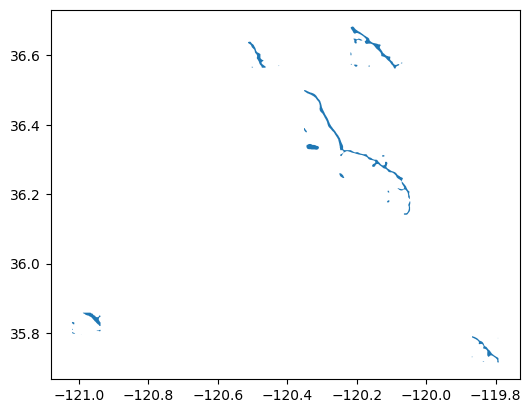

In [19]:
properties_list = []
geometries = []
for red in final_ensemble['features']:
    # Extract geometry and properties
    geometry = shape(red["geometry"])
    properties = red["properties"]

    # Append to lists
    geometries.append(geometry)
    properties_list.append(properties)
# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(properties_list, geometry=geometries)
gdf.plot()

In [20]:
gdf.to_file('AADA_maskrcnn.geojson', driver='GeoJSON')